/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_31236/3158821559.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


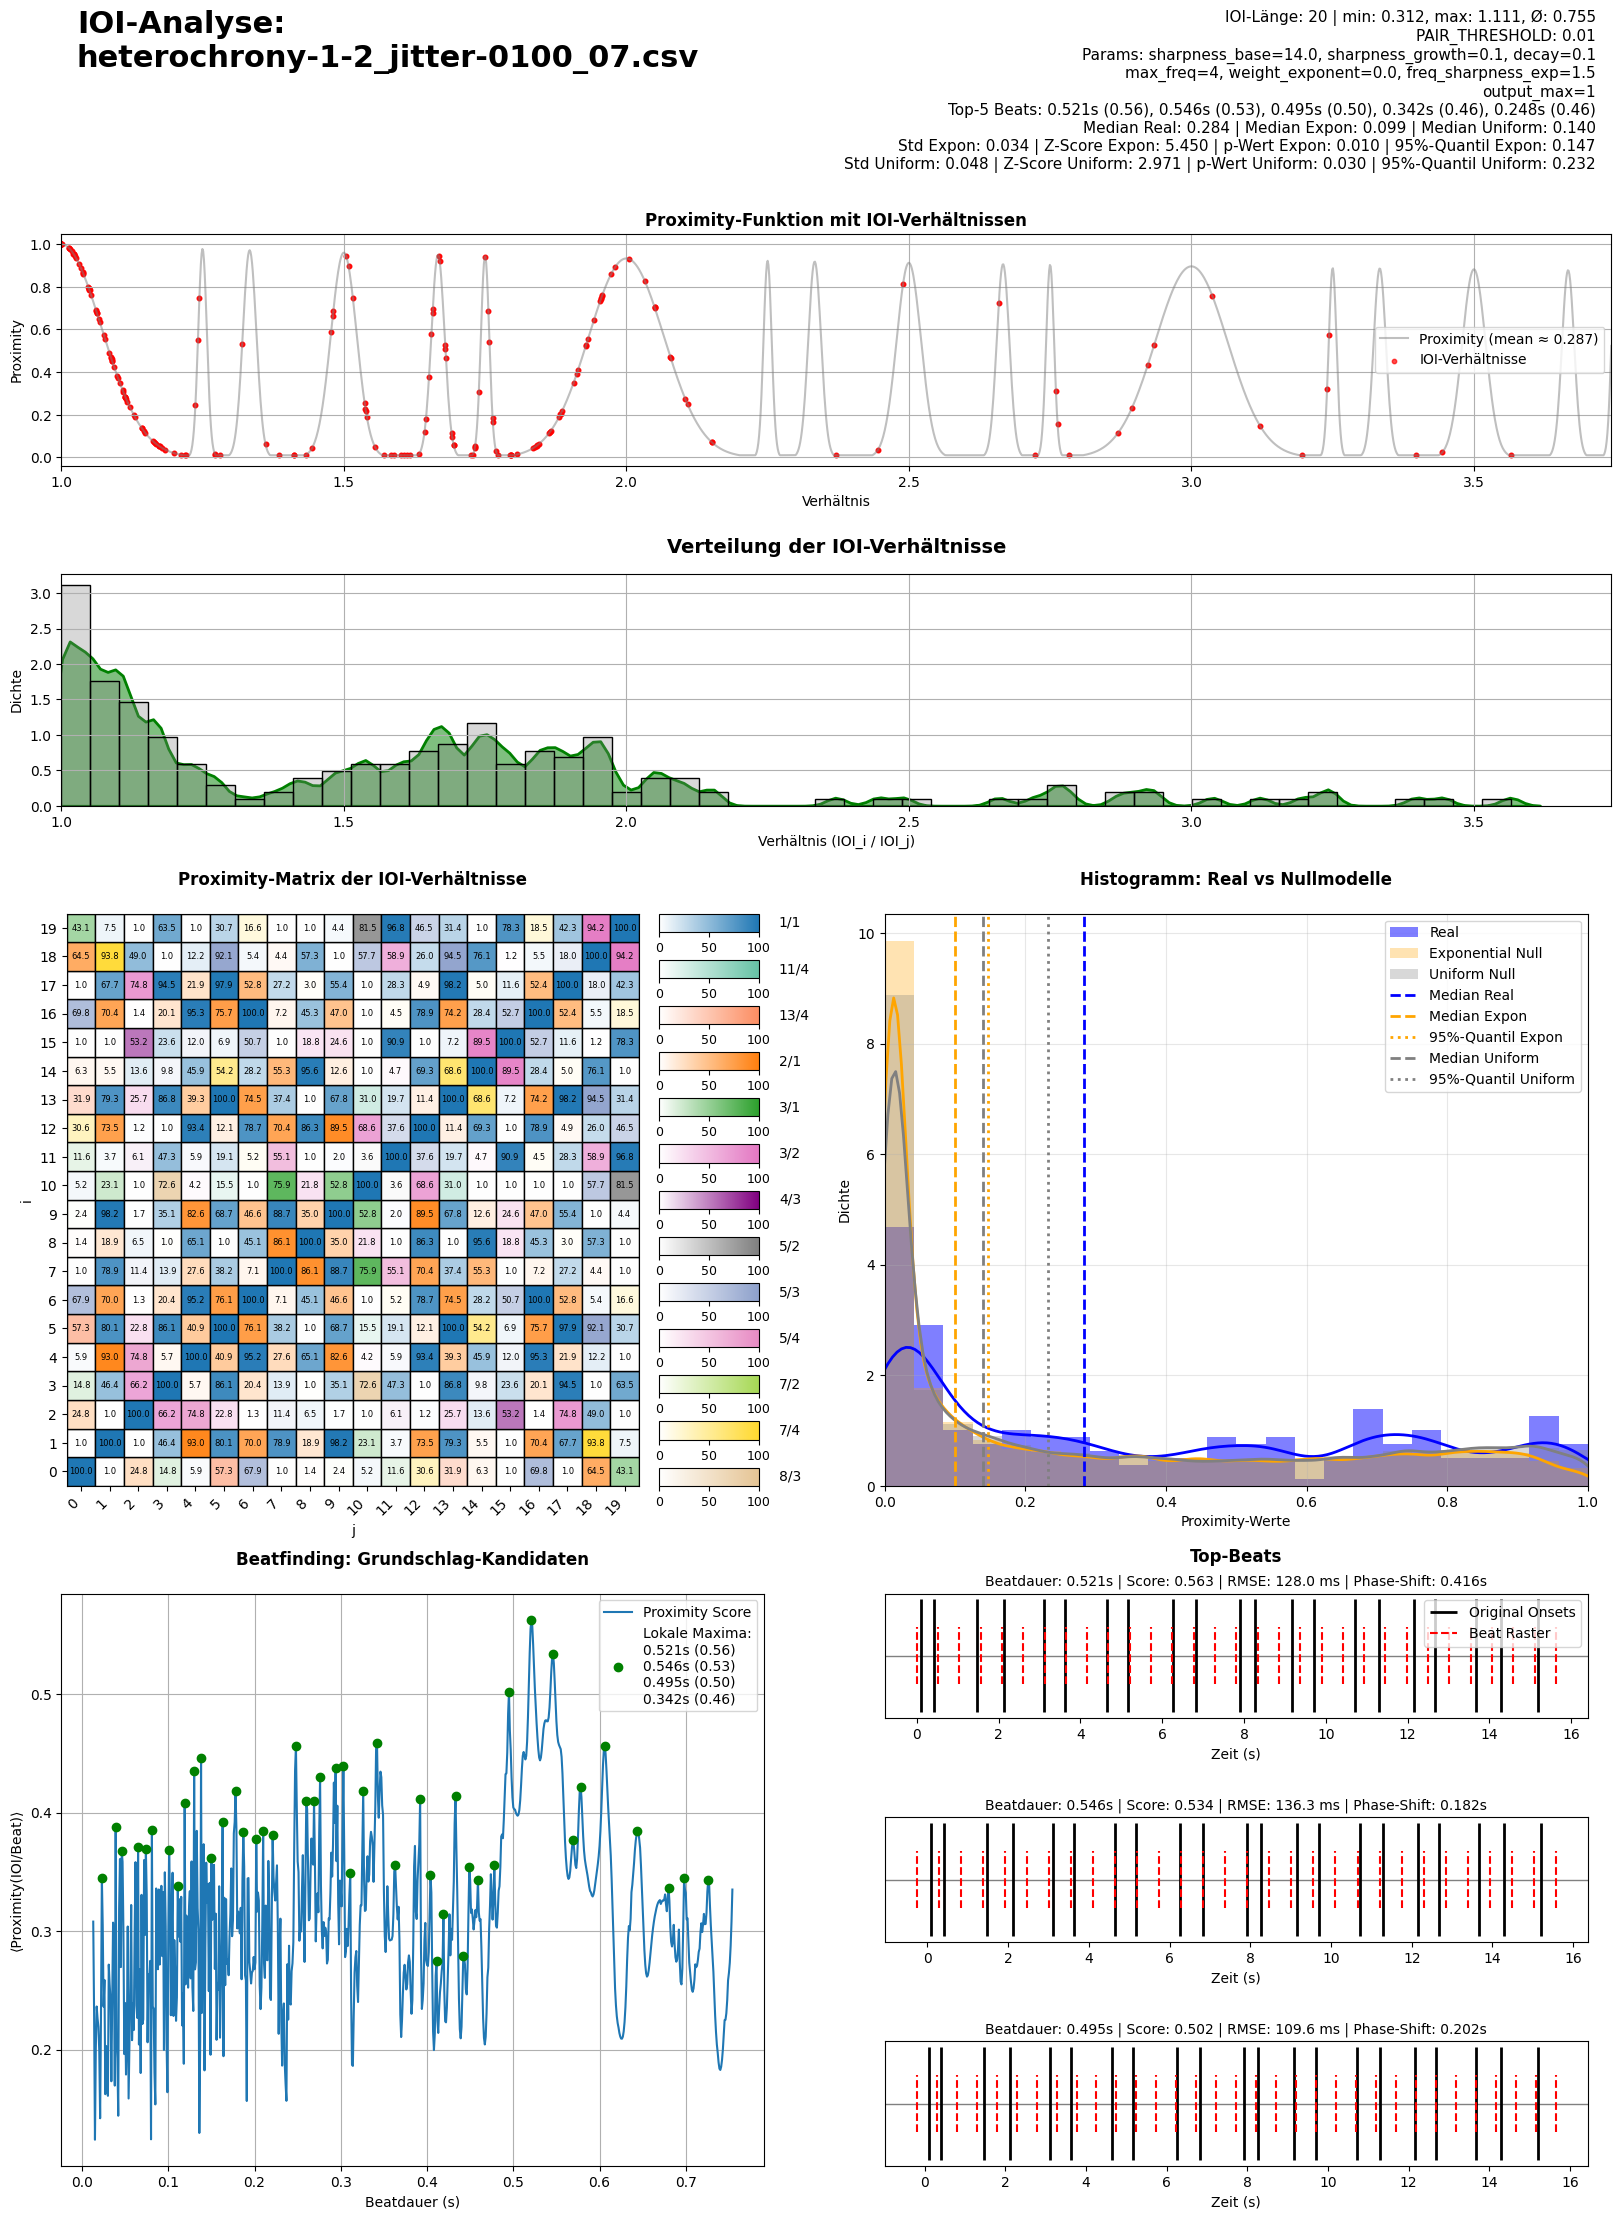

In [1]:
# miau miau

# ausreichende Initialisierung ohne Plots
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec

# Tabellen der Ergebnisse für verschiedene Datensätze erstellen
# (für Veröffentlichung und Bericht)

import sys
from pathlib import Path

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate

importlib.reload(prox)

# =============================
# 4) Parameter, Daten laden & Pairs bauen
# =============================

filename = "heterochrony-1-2_jitter-0100_07.csv"
base_dir = Path("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

# Nur gültige IOIs verwenden
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# ---- NEU: build_pairwise_proximity_df verwenden ----
df_pairs, ratios, prox_max = prox.build_pairwise_proximity_df(iois, prox.default_params_table)

# Dynamische Grenzen aus den Daten bestimmen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
x_max = df_pairs["ratio"].max() * 1.05

# Blaue Kurve über den ganzen Plotbereich
x_range = np.linspace(x_min, x_max, 2000)
y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **prox.default_params_table)

# Mittelwert für diesen Bereich
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# Pivot-Matrizen für Plot vorbereiten
pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")


unique_labels = sorted(set(df_pairs["peak_label"]))

# --- Fixe Farbzuordnung für kleine Brüche ---
tab10 = plt.cm.tab10.colors  

fixed_colors = {
    "1/1": tab10[0],  # blau
    "2/1": tab10[1],  # orange
    "3/1": tab10[2],  # grün
    "4/1": tab10[3],  # rot
    "5/1": tab10[4],  # lila
    "1/2": tab10[5],  # braun
    "3/2": tab10[6],  # pink
    "5/2": tab10[7],  # grau
    "1/3": tab10[8],  # olivgrün
    "2/3": tab10[9],  # hellblau
    "4/3": (0.5, 0.0, 0.5)  # extra-farbe (dunkelviolett), da tab10 nur 10 hat
}

label_to_cmap = {}

# Zuerst feste Farben vergeben
for label, color in fixed_colors.items():
    if label in unique_labels:
        cmap_colors = [(1,1,1), plt.cm.colors.to_rgb(color)]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# Rest wie vorher aus Palette
remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
palette = sns.color_palette("Set2", len(remaining_labels))
for label, base_color in zip(remaining_labels, palette):
    cmap_colors = [(1,1,1), base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === 3) Kombiniertes Histogramm mit Anteilen + 95%-Quantil ===

results = prox.analyze_single_sequence(iois, params=prox.default_params_table, num_sequences=100, seed=42, bins=25, plot=False)

# === 4) Beatfinding via Kandidaten und lokalen Maxima ===

# =============================
# 2) Hilfsfunktionen
# =============================

# =============================
# 7) Beat-Kandidaten
# =============================
beat_candidates = prox.generate_beat_candidates_from_iois(iois)
scores = [prox.score_for_beat(beat, iois, prox.default_params_table) for beat in beat_candidates]
local_maxima = prox.find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 8) Top-5 Onset-Fit
# =============================

# -----------------------------
# Figure vorbereiten
# -----------------------------
fig = plt.figure(figsize=(20, 28))

# GridSpec: jetzt 7 Zeilen
gs = gridspec.GridSpec(
    7, 2, figure=fig,
    width_ratios=[1, 1],
    height_ratios=[0.5, 1, 1, 1, 1, 1, 1],
    hspace=0.5, wspace=0.3
)

# -----------------------------
# Header
# -----------------------------
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.text(
    0.01, 1.0,
    f"IOI-Analyse:\n{filename}",
    transform=ax_header.transAxes,
    fontsize=22, fontweight='bold',
    va='top', ha='left'
)

# Rechter Zusatz oben rechts
info_lines = [
    f"IOI-Länge: {len(iois)} | min: {np.min(iois):.3f}, max: {np.max(iois):.3f}, Ø: {np.mean(iois):.3f}",
    f"PAIR_THRESHOLD: {prox.default_params_table['threshold']}",
    f"Params: sharpness_base={prox.default_params_table['sharpness_base']}, sharpness_growth={prox.default_params_table['sharpness_growth']}, decay={prox.default_params_table['decay']}",
    f"max_freq={prox.default_params_table['max_freq']}, weight_exponent={prox.default_params_table['weight_exponent']}, freq_sharpness_exp={prox.default_params_table['freq_sharpness_exp']}",
    f"output_max={prox.default_params_table['output_max']}",
    f"Top-5 Beats: " + ", ".join([f"{b:.3f}s ({s:.2f})" for b,s in local_maxima_top5[:5]]),
    f"Median Real: {results['results']['median_real']:.3f} | Median Expon: {results['results']['median_expon']:.3f} | Median Uniform: {results['results']['median_uniform']:.3f}",
    f"Std Expon: {results['results']['std_expon']:.3f} | Z-Score Expon: {results['results']['zscore_expon']:.3f} | p-Wert Expon: {results['results']['pval_expon']:.3f} | 95%-Quantil Expon: {results['results']['quant95_expon']:.3f}", 
    f"Std Uniform: {results['results']['std_uniform']:.3f} | Z-Score Uniform: {results['results']['zscore_uniform']:.3f} | p-Wert Uniform: {results['results']['pval_uniform']:.3f} | 95%-Quantil Uniform: {results['results']['quant95_uniform']:.3f}"
]

ax_header.text(
    0.99, 1.0,                       # oben rechts
    "\n".join(info_lines),
    transform=ax_header.transAxes,
    fontsize=11,
    va='top',
    ha='right'
)

# -----------------------------
# 1) Proximity-Funktion
# -----------------------------
# Gemeinsame X-Achsen-Grenzen berechnen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
x_max = df_pairs["ratio"].max() * 1.05

# -----------------------------
# 1) Proximity-Funktion
# -----------------------------
ax1 = fig.add_subplot(gs[1, :])
x_range = np.linspace(x_min, x_max, 2000)
y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **prox.default_params_table)
mean_prox = np.mean(y_curve)
ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="grey")
ax1.scatter(df_pairs["ratio"].values, df_pairs["prox_value"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen", fontweight='bold')
ax1.set_xlabel("Verhältnis")
ax1.set_ylabel("Proximity")
ax1.grid(True)
ax1.legend()
ax1.set_xlim(x_min, x_max)   # <--- hier!

# -----------------------------
# 2) Verteilung IOI-Verhältnisse (neu!)
# -----------------------------
ax2 = fig.add_subplot(gs[2, :])
sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.1, ax=ax2)
sns.histplot(df_pairs["ratio"], bins=50, color="gray", alpha=0.3, stat="density", ax=ax2)

ax2.set_title("Verteilung der IOI-Verhältnisse", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Verhältnis (IOI_i / IOI_j)")
ax2.set_ylabel("Dichte")
ax2.set_xlim(x_min, x_max)
ax2.grid(True)

# -----------------------------
# 3) Recurrence-Matrix links
# -----------------------------
ax3 = fig.add_subplot(gs[3:5, 0])
# -----------------------------
pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")
n = len(iois)

for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]

    # Falls NaN -> weiß färben
    if np.isnan(val):
        color = (1, 1, 1, 1)
    else:
        color = cmap(val / 100)

    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax3.add_patch(rect)

    # Werte in kleine Matrizen schreiben
    if n <= 20 and not np.isnan(val):
        ax3.text(
            j + 0.5, i + 0.5,
            f"{float(val.item()):.1f}",
            ha='center', va='center',
            fontsize=6, color="black"
        )


ax3.set_xlim(0, n)
ax3.set_ylim(0, n)
ax3.set_aspect('equal')
ax3.set_xticks(np.arange(n)+0.5)
ax3.set_yticks(np.arange(n)+0.5)
ax3.set_xticklabels(range(n), rotation=45, ha="right")
ax3.set_yticklabels(range(n))
ax3.set_xlabel("j")
ax3.set_ylabel("i")
ax3.set_title("Proximity-Matrix der IOI-Verhältnisse\n", fontweight='bold')

# aktuelle Position auslesen
pos = ax3.get_position()

# leicht nach links verschieben (x0 und x1 kleiner machen)
shift = 0.0227   # Feinjustieren!
ax3.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

# neue Position nach dem Verschieben holen
pos = ax3.get_position()

# Farbskalen rechts der Matrix
unique_labels = sorted(set(df_pairs["peak_label"]))
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

cbar_width = 0.05
spacing = 0.01
n_labels = len(legend_labels)
bar_height = (pos.height - (n_labels-1)*spacing) / n_labels

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar_y = pos.y0 + pos.height - (idx+1)*bar_height - idx*spacing
    cbar_ax = fig.add_axes([pos.x1 + 0.01, cbar_y, cbar_width, bar_height])
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation="horizontal"
    )
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)
    fig.text(pos.x1 + 0.07, cbar_y + bar_height/2, label, va='center', fontsize=10)

# -----------------------------
# 4) Histogramm rechts
# -----------------------------
ax4 = fig.add_subplot(gs[3:5, 1])
colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
bin_edges = np.linspace(0, 1, 25)
ax4.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
ax4.hist(results["proximity_expon_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Exponential Null")
ax4.hist(results["proximity_uniform_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Uniform Null")
sns.kdeplot(results["proximity_real"], bw_adjust=0.4, color=colors["Real"], linewidth=2, ax=ax4)
sns.kdeplot(results["proximity_expon_all"], bw_adjust=0.4, color=colors["Expon"], linewidth=2, ax=ax4)
sns.kdeplot(results["proximity_uniform_all"], bw_adjust=0.4, color=colors["Uniform"], linewidth=2, ax=ax4)
ax4.axvline(results["results"]["median_real"], color=colors["Real"], linestyle="--", linewidth=2, label="Median Real")
ax4.axvline(results["results"]["median_expon"], color=colors["Expon"], linestyle="--", linewidth=2, label="Median Expon")
ax4.axvline(results["results"]["quant95_expon"], color=colors["Expon"], linestyle=":", linewidth=2, label="95%-Quantil Expon")
ax4.axvline(results["results"]["median_uniform"], color=colors["Uniform"], linestyle="--", linewidth=2, label="Median Uniform")
ax4.axvline(results["results"]["quant95_uniform"], color=colors["Uniform"], linestyle=":", linewidth=2, label="95%-Quantil Uniform")
ax4.set_xlim(0, 1)
ax4.set_xlabel("Proximity-Werte")
ax4.set_ylabel("Dichte")
ax4.set_title("Histogramm: Real vs Nullmodelle\n", fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

target_width = 0.3515294117647057  # gemessene Breite der Matrix + Skala

pos_other = ax4.get_position()
ax4.set_position([pos_other.x0, pos_other.y0, target_width, pos_other.height])

# aktuelle Position auslesen
pos = ax4.get_position()

# leicht nach links verschieben (x0 und x1 kleiner machen)
shift_right = 0.0263   # Feinjustieren!
ax4.set_position([pos.x0 - shift_right, pos.y0, pos.width, pos.height])

# neue Position nach dem Verschieben holen
pos = ax4.get_position()

# -----------------------------
# 5) Beat-Kandidaten
# -----------------------------
ax5 = fig.add_subplot(gs[5:7, 0])
ax5.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    ax5.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5[:4]]
ax5.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
ax5.set_xlabel("Beatdauer (s)")
ax5.set_ylabel("⟨Proximity(IOI/Beat)⟩")
ax5.set_title("Beatfinding: Grundschlag-Kandidaten\n", fontweight='bold')
ax5.grid(True)
ax5.legend()

target_width = 0.3515294117647057  # von oben gemessen

# Linke Seite (Beat-Kandidaten)
pos_left = ax5.get_position()
ax5.set_position([pos_left.x0, pos_left.y0, target_width, pos_left.height])

# Rechte Spalte: Top-Beats
height_ratios = [0.9, 0.9, 0.9]
right_gs = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs[5:7, 1],
    hspace=0.8, height_ratios=height_ratios
)

n_top_display = min(3, len(local_maxima_top5))
ax_tops = []  # hier speichern wir die Subplots
for idx in range(n_top_display):
    ax_top = fig.add_subplot(right_gs[idx])
    ax_tops.append(ax_top)

    beat, score = local_maxima_top5[idx]
    best_shift, best_rmse, best_beats = prox.compute_beat_rmse(onsets, beat)

    ax_top.axhline(0, color='gray', linewidth=1)
    ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2,
                  label='Original Onsets' if idx==0 else "")
    ax_top.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--',
                  label='Beat Raster' if idx==0 else "")

    title = (f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
             f"RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s")
    ax_top.set_title(title, fontsize=10)
    ax_top.set_yticks([])
    ax_top.set_xlabel("Zeit (s)")
    if idx == 0:
        ax_top.legend(loc='upper right')

# --- Breite angleichen (nach dem Zeichnen!) ---
for ax_top in ax_tops:
    pos = ax_top.get_position()
    ax_top.set_position([pos.x0 - shift_right, pos.y0, target_width, pos.height])

# Position der rechten Spalte über die Achsen bestimmen
top_ax_pos = ax_tops[0].get_position()       # ganz oben
bottom_ax_pos = ax_tops[-1].get_position()   # ganz unten

# Bounding Box für die Spalte
x0 = top_ax_pos.x0
x1 = top_ax_pos.x1
y0 = bottom_ax_pos.y0
y1 = top_ax_pos.y1

# --- Gemeinsamer Titel für die ganze Spalte ---
# Statt y1 + 0.02 -> etwas weiter unten, wie ax.set_title()
fig.text(
    (x0 + x1)/2,
    y1 + 0.01,    # etwas tiefer, damit es wie ein normaler Plot-Titel wirkt
    "Top-Beats",
    ha="center", va="bottom",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()


In [ ]:
# ===============================================
# IOI-Analyse & Beat-Detektion
# ===============================================

# =============================
# 0) Imports
# =============================
import sys
from pathlib import Path
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
from tabulate import tabulate

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

# Proximity-Library laden
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# 1) Parameter, Daten laden & Pairs bauen
# =============================
# =============================
# 0) Datei + Parameter Auswahl
# =============================
from pathlib import Path
import proximitylib.proximity as prox

# === Datei auswählen ===
filename = "heterochrony-1-2_jitter-0100_07.csv"
base_dir = Path("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/100beats/")
seq_path = base_dir / filename

# === Parameter-Sets definieren ===
param_sets = {
    "iso": prox.default_params_iso,
    1: prox.default_params_1,
    2: prox.default_params_2,
    3: prox.default_params_3,
    4: prox.default_params_4
}

# === Parameter auswählen ===
param_choice = 2         # choose "iso", 1, 2, 3, or 4
params = param_sets[param_choice]

print(f"Verwendetes Parameter-Dict: default_params_{param_choice}")


if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairwise Proximity berechnen
df_pairs, ratios, prox_max = prox.build_pairwise_proximity_df(iois, params)

# Dynamische Grenzen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
x_max = df_pairs["ratio"].max() * 1.05
x_range = np.linspace(x_min, x_max, 2000)
y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **params)
mean_prox = np.mean(y_curve)

# Pivot-Matrizen
pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

# =============================
# 2) Farben / Colormaps
# =============================
unique_labels = sorted(set(df_pairs["peak_label"]))
tab10 = plt.cm.tab10.colors  

fixed_colors = {
    "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
    "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
    "4/3": (0.5, 0.0, 0.5)
}

label_to_cmap = {}
# feste Farben
for label, color in fixed_colors.items():
    if label in unique_labels:
        cmap_colors = [(1, 1, 1), plt.cm.colors.to_rgb(color)]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# restliche Labels aus Palette
remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
palette = sns.color_palette("Set2", len(remaining_labels))
for label, base_color in zip(remaining_labels, palette):
    cmap_colors = [(1, 1, 1), base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# =============================
# 3) Analyse: Histogramme, Nullmodelle
# =============================
results = prox.analyze_single_sequence(
    iois,
    params=params,
    num_sequences=100,
    seed=42,
    bins=25,
    plot=False
)

# =============================
# 4) Beat-Kandidaten
# =============================
beat_candidates = prox.generate_beat_candidates_from_iois(iois)
scores = [prox.score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = prox.find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 5) Plot Figure
# =============================
fig = plt.figure(figsize=(20, 28))
gs = gridspec.GridSpec(7, 2, figure=fig, width_ratios=[1, 1], height_ratios=[0.5, 1, 1, 1, 1, 1, 1], hspace=0.5, wspace=0.3)

# --- Header ---
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.text(0.01, 1.0, f"IOI-Analyse:\n{filename}", transform=ax_header.transAxes, fontsize=22, fontweight='bold', va='top', ha='left')

info_lines = [
    f"IOI-Länge: {len(iois)} | min: {np.min(iois):.3f}, max: {np.max(iois):.3f}, Ø: {np.mean(iois):.3f}",
    f"PAIR_THRESHOLD: {params['threshold']}",
    f"Params: sharpness_base={params['sharpness_base']}, sharpness_growth={params['sharpness_growth']}, decay={params['decay']}",
    f"max_freq={params['max_freq']}, weight_exponent={params['weight_exponent']}, freq_sharpness_exp={params['freq_sharpness_exp']}",
    f"output_max={params['output_max']}",
    f"Top-5 Beats: " + ", ".join([f"{b:.3f}s ({s:.2f})" for b, s in local_maxima_top5[:5]]),
    f"Median Real: {results['results']['median_real']:.3f} | Median Expon: {results['results']['median_expon']:.3f} | Median Uniform: {results['results']['median_uniform']:.3f}",
    f"Std Expon: {results['results']['std_expon']:.3f} | Z-Score Expon: {results['results']['zscore_expon']:.3f} | p-Wert Expon: {results['results']['pval_expon']:.3f} | 95%-Quantil Expon: {results['results']['quant95_expon']:.3f}",
    f"Std Uniform: {results['results']['std_uniform']:.3f} | Z-Score Uniform: {results['results']['zscore_uniform']:.3f} | p-Wert Uniform: {results['results']['pval_uniform']:.3f} | 95%-Quantil Uniform: {results['results']['quant95_uniform']:.3f}"
]

ax_header.text(0.99, 1.0, "\n".join(info_lines), transform=ax_header.transAxes, fontsize=11, va='top', ha='right')

# --- Proximity-Funktion Plot ---
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="grey")
ax1.scatter(df_pairs["ratio"].values, df_pairs["prox_value"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen", fontweight='bold')
ax1.set_xlabel("Verhältnis")
ax1.set_ylabel("Proximity")
ax1.grid(True)
ax1.legend()
ax1.set_xlim(x_min, x_max)

# --- IOI-Verhältnis Verteilung ---
ax2 = fig.add_subplot(gs[2, :])
sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.1, ax=ax2)
sns.histplot(df_pairs["ratio"], bins=50, color="gray", alpha=0.3, stat="density", ax=ax2)
ax2.set_title("Verteilung der IOI-Verhältnisse", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Verhältnis (IOI_i / IOI_j)")
ax2.set_ylabel("Dichte")
ax2.set_xlim(x_min, x_max)
ax2.grid(True)

# --- Proximity-Matrix (Recurrence) ---
ax3 = fig.add_subplot(gs[3:5, 0])
n = len(iois)
for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100) if not np.isnan(val) else (1, 1, 1, 1)
    ax3.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black'))
    if n <= 20 and not np.isnan(val):
        ax3.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

ax3.set_xlim(0, n)
ax3.set_ylim(0, n)
ax3.set_aspect('equal')
ax3.set_xticks(np.arange(n)+0.5)
ax3.set_yticks(np.arange(n)+0.5)
ax3.set_xticklabels(range(n), rotation=45, ha="right")
ax3.set_yticklabels(range(n))
ax3.set_xlabel("j")
ax3.set_ylabel("i")
ax3.set_title("Proximity-Matrix der IOI-Verhältnisse\n", fontweight='bold')

# Farbskalen rechts
pos = ax3.get_position()
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]
cbar_width = 0.05
spacing = 0.01
n_labels = len(legend_labels)
bar_height = (pos.height - (n_labels-1)*spacing) / n_labels
for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar_y = pos.y0 + pos.height - (idx+1)*bar_height - idx*spacing
    cbar_ax = fig.add_axes([pos.x1 + 0.01, cbar_y, cbar_width, bar_height])
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)
    fig.text(pos.x1 + 0.07, cbar_y + bar_height/2, label, va='center', fontsize=10)

# --- Histogramm rechts ---
ax4 = fig.add_subplot(gs[3:5, 1])
colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
bin_edges = np.linspace(0, 1, 25)
ax4.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
ax4.hist(results["proximity_expon_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Exponential Null")
ax4.hist(results["proximity_uniform_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Uniform Null")
sns.kdeplot(results["proximity_real"], bw_adjust=0.4, color=colors["Real"], linewidth=2, ax=ax4)
sns.kdeplot(results["proximity_expon_all"], bw_adjust=0.4, color=colors["Expon"], linewidth=2, ax=ax4)
sns.kdeplot(results["proximity_uniform_all"], bw_adjust=0.4, color=colors["Uniform"], linewidth=2, ax=ax4)
ax4.axvline(results["results"]["median_real"], color=colors["Real"], linestyle="--", linewidth=2, label="Median Real")
ax4.axvline(results["results"]["median_expon"], color=colors["Expon"], linestyle="--", linewidth=2, label="Median Expon")
ax4.axvline(results["results"]["quant95_expon"], color=colors["Expon"], linestyle=":", linewidth=2, label="95%-Quantil Expon")
ax4.axvline(results["results"]["median_uniform"], color=colors["Uniform"], linestyle="--", linewidth=2, label="Median Uniform")
ax4.axvline(results["results"]["quant95_uniform"], color=colors["Uniform"], linestyle=":", linewidth=2, label="95%-Quantil Uniform")
ax4.set_xlim(0, 1)
ax4.set_xlabel("Proximity-Werte")
ax4.set_ylabel("Dichte")
ax4.set_title("Histogramm: Real vs Nullmodelle\n", fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

# --- Beat-Kandidaten Plot ---
ax5 = fig.add_subplot(gs[5:7, 0])
ax5.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    ax5.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5[:4]]
ax5.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
ax5.set_xlabel("Beatdauer (s)")
ax5.set_ylabel("⟨Proximity(IOI/Beat)⟩")
ax5.set_title("Beatfinding: Grundschlag-Kandidaten\n", fontweight='bold')
ax5.grid(True)
ax5.legend()

# Rechte Spalte: Top-Beats
right_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[5:7, 1], hspace=0.8, height_ratios=[0.9]*3)
ax_tops = []
for idx in range(min(3, len(local_maxima_top5))):
    ax_top = fig.add_subplot(right_gs[idx])
    ax_tops.append(ax_top)
    beat, score = local_maxima_top5[idx]
    best_shift, best_rmse, best_beats = prox.compute_beat_rmse(onsets, beat)
    ax_top.axhline(0, color='gray', linewidth=1)
    ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets' if idx==0 else "")
    ax_top.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--', label='Beat Raster' if idx==0 else "")
    title = f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s"
    ax_top.set_title(title, fontsize=10)
    ax_top.set_yticks([])
    ax_top.set_xlabel("Zeit (s)")
    if idx == 0:
        ax_top.legend(loc='upper right')

plt.tight_layout()
plt.show()